In [1]:
# Import Libraries

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

In [2]:
# Load Dataset

df = pd.read_csv("customer_churn_feature_engineered.csv")

df.head()

,CustomerID,Count,Country,State,City,Zip_Code,Lat_Long,Latitude,Longitude,Gender,...,Tenure_Group,Monthly_Charge_Category,CLTV_Category,Total_Services,High_Value_Customer,Customer_Segment,Risk_Level,Revenue_Category,Customer_Age_Group,Customer_Status
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,0-12 Months,Medium,Low,3,No,Silver,High Risk,Low,Adult,Inactive
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,0-12 Months,High,Low,1,No,Standard,Medium Risk,Low,Adult,Inactive
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,0-12 Months,High,High,5,Yes,Premium,High Risk,Medium,Adult,Inactive
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,25-48 Months,High,Medium,6,Yes,Premium,High Risk,High,Adult,Inactive
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,49-72 Months,High,High,6,Yes,Premium,High Risk,High,Adult,Inactive


In [3]:
print(df.columns.tolist())

['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip_Code', 'Lat_Long', 'Latitude', 'Longitude', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents', 'Tenure_Months', 'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn_Label', 'Churn_Value', 'Churn_Score', 'CLTV', 'Churn_Reason', 'Tenure_Group', 'Monthly_Charge_Category', 'CLTV_Category', 'Total_Services', 'High_Value_Customer', 'Customer_Segment', 'Risk_Level', 'Revenue_Category', 'Customer_Age_Group', 'Customer_Status']


In [4]:
# Drop unnecessary and leakage columns

df = df.drop(
    columns=[
        "CustomerID",
        "Count",
        "Country",
        "State",
        "City",
        "Zip_Code",
        "Lat_Long",
        "Latitude",
        "Longitude",
        "Churn_Label",
        "Churn_Score",
        "Customer_Status",
        "Churn_Category",
        "Churn_Reason"
    ],
    errors="ignore"
)

print(df.columns.tolist())

['Gender', 'Senior_Citizen', 'Partner', 'Dependents', 'Tenure_Months', 'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn_Value', 'CLTV', 'Tenure_Group', 'Monthly_Charge_Category', 'CLTV_Category', 'Total_Services', 'High_Value_Customer', 'Customer_Segment', 'Risk_Level', 'Revenue_Category', 'Customer_Age_Group']


In [5]:
X = df.drop("Churn_Value", axis=1)

y = df["Churn_Value"]

In [6]:
categorical_columns = X.select_dtypes(include=["object"]).columns

le = LabelEncoder()

for col in categorical_columns:
    X[col] = le.fit_transform(X[col])

print("Encoding Completed")

Encoding Completed


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [8]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
rf_predictions = rf_model.predict(X_test)

In [10]:
print("Accuracy :", accuracy_score(y_test, rf_predictions))

Accuracy : 0.9091554293825408


In [11]:
print("Precision :", precision_score(y_test, rf_predictions))

Precision : 0.8867924528301887


In [12]:
print("Recall :", recall_score(y_test, rf_predictions))

Recall : 0.7540106951871658


In [13]:
print("F1 Score :", f1_score(y_test, rf_predictions))

F1 Score : 0.815028901734104


In [14]:
print("ROC AUC :", roc_auc_score(y_test, rf_predictions))

ROC AUC : 0.8596140432457567


In [15]:
cm = confusion_matrix(y_test, rf_predictions)

print(cm)

[[999  36]
 [ 92 282]]


In [16]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1035
           1       0.89      0.75      0.82       374

    accuracy                           0.91      1409
   macro avg       0.90      0.86      0.88      1409
weighted avg       0.91      0.91      0.91      1409



In [17]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
26,Risk_Level,0.469731
14,Contract,0.092857
4,Tenure_Months,0.064183
17,Monthly_Charges,0.043656
8,Online_Security,0.042045
18,Total_Charges,0.040844
20,Tenure_Group,0.033180
11,Tech_Support,0.029844
3,Dependents,0.027017
19,CLTV,0.021488


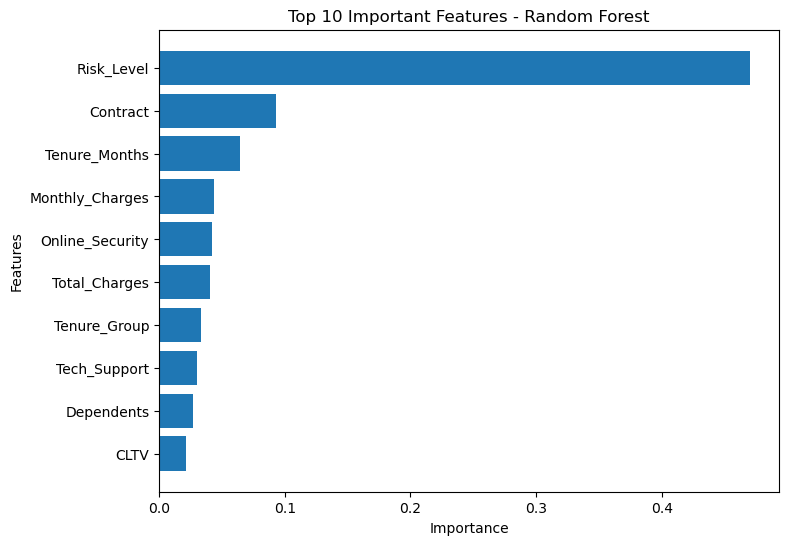

In [18]:
plt.figure(figsize=(8,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features - Random Forest")

plt.gca().invert_yaxis()

plt.show()

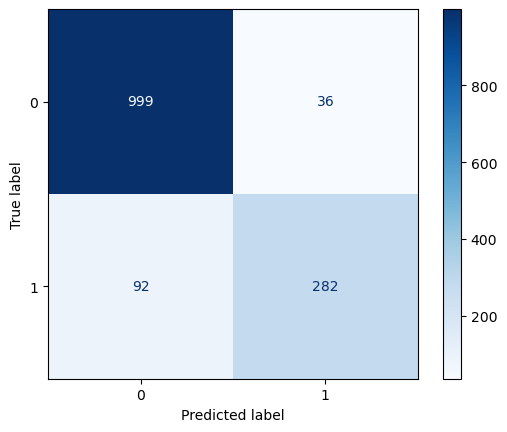

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.show()

In [20]:
rf_probabilities = rf_model.predict_proba(X_test)[:,1]

rf_probabilities[:10]

array([0.01525822, 0.40801081, 0.05913238, 0.35521555, 0.01575013,
       0.46612112, 0.19159898, 0.04026096, 0.00420898, 0.27543358])

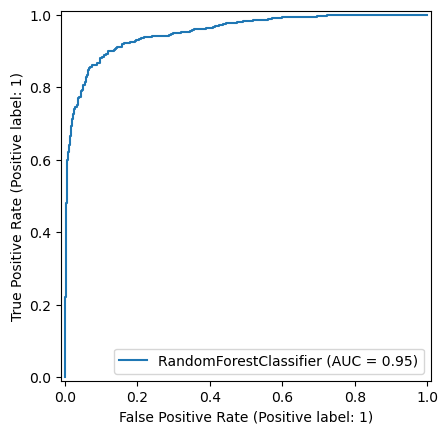

In [21]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.show()

In [22]:
import joblib

joblib.dump(rf_model, "random_forest_model.pkl")

print("Random Forest Model Saved Successfully!")

Random Forest Model Saved Successfully!


In [23]:
print(X.columns.tolist())

['Gender', 'Senior_Citizen', 'Partner', 'Dependents', 'Tenure_Months', 'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'CLTV', 'Tenure_Group', 'Monthly_Charge_Category', 'CLTV_Category', 'Total_Services', 'High_Value_Customer', 'Customer_Segment', 'Risk_Level', 'Revenue_Category', 'Customer_Age_Group']
